In [1]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("filtered_metadata.csv")
df = df[(df['modeled_seq_len'] > 31) & (df['modeled_seq_len'] <= 384)]
df = df[(df['coil_percent'] < 0.5)]
afdb_df = df[df.pdb_name.str.contains("model_v4")]
pdb_df = df[~df.pdb_name.str.contains("model_v4")]

/scratch/alexjli/ipykernel_2544383/1745512581.py:4: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("filtered_metadata.csv")


In [2]:
cluster_groupby = pdb_df.groupby('cluster')

In [3]:
cluster_groupby['seq_len'].mean()

cluster
0         375.578947
1         243.390728
2         187.416667
8         255.000000
12        316.302239
             ...    
915129    258.000000
915130    415.000000
915137    238.000000
915140    146.000000
915170    214.000000
Name: seq_len, Length: 7318, dtype: float64

<Axes: xlabel='modeled_seq_len', ylabel='Count'>

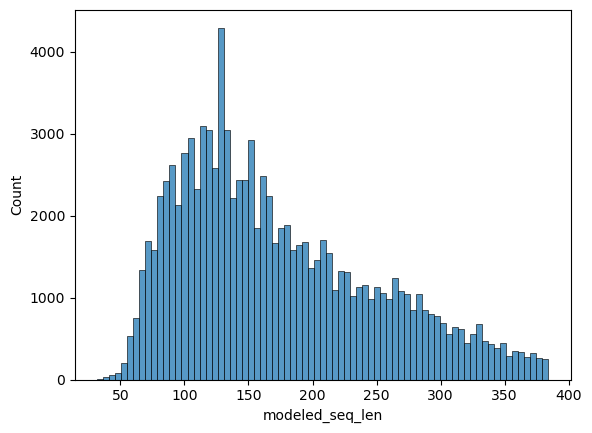

In [4]:
sns.histplot(df, x="modeled_seq_len")

In [5]:
print(len(pdb_df['cluster'].unique()), len(pdb_df), len(pdb_df)-len(pdb_df['cluster'].unique()))
print(len(afdb_df['cluster'].unique()), len(afdb_df))
print(len(df['cluster'].unique()), len(df), len(df) - len(df['cluster'].unique()))


7318 22250 14932
77352 77352
84670 99602 14932


In [6]:
df['modeled_seq_len'].mean()

172.76666131202185

In [7]:
cluster_groupby['seq_len'].mean().mean()

314.7035249009689

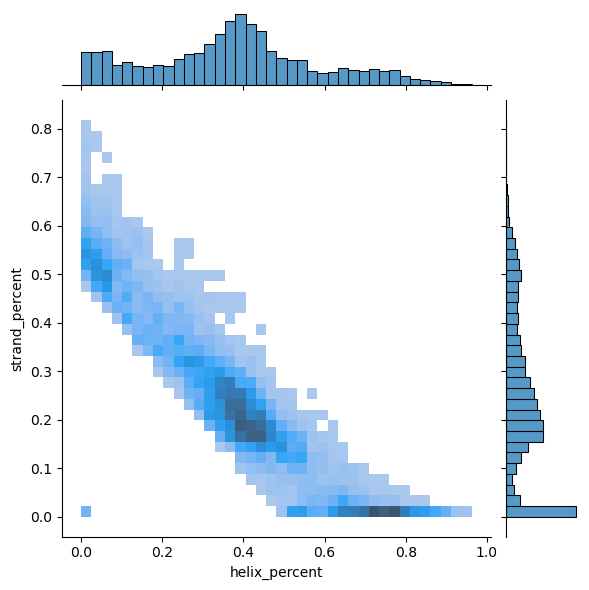

In [8]:
jointplot = sns.jointplot(pdb_df.groupby("cluster").sample(1), x="helix_percent", y="strand_percent", kind='hist')
# jointplot.ax_joint.set(xlabel="Fraction Helix", ylabel="Fraction Strand")
# plt.xlim(0,1)
# plt.ylim(0,1)

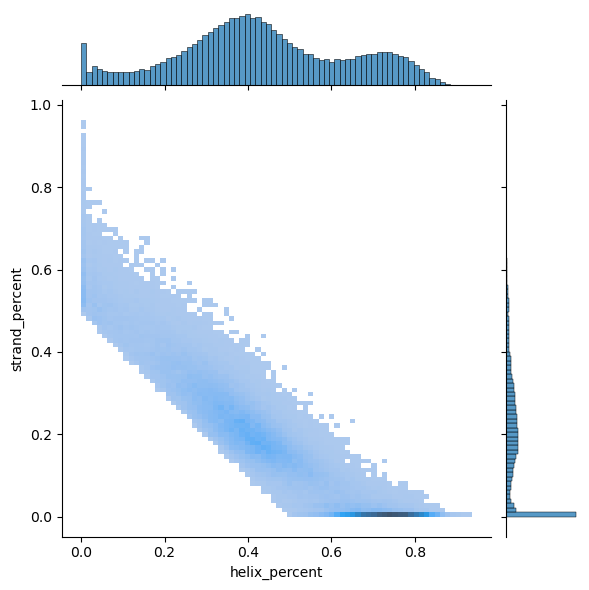

In [9]:
sns.jointplot(afdb_df.groupby("cluster").sample(1), x="helix_percent", y="strand_percent", kind='hist')